# Lab 5: Conditioning Signals

Your Name:  <span style="background-color:yellow">Cole Stevens</span>

**Laboratory Outcomes**

1. Design, construct and characterize an RLC bandpass circuit
2. Design, construct and characterize a circuit to reduce a signal
3. Design, construct and characterize an amplifier circuit using an op-amp

## Context:  Interfacing the world to a computer

**Example**: Suppose you want to measure and record the temperature of a liquid as a function of time.  You could get a thermometer and write down numbers every so often.  If you wanted to take data over a long period of time (hours, days) or you wanted to get data quickly (every 10 seconds) that might not be reasonable with paper and pencil. But we are learning how to have the computer help us do this type of measurement.

To interrogate the natural world and get a signal into our computer we need to 

* get a signal from the world using a transducer, 
* reduce, amplify, filter, etc. the signal so it is appropriate for an interface,
* connect to an interface, and
* connect the interface to a computer.

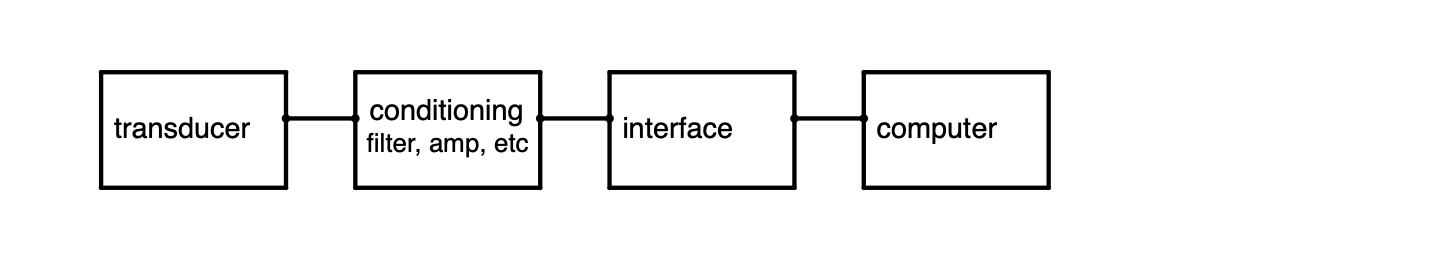

Figure: Getting data from the world to a computer diagram.

Let's talk about the first and last steps in this process.
A **transducer** is a device that changes some physical property in response to changes in another physical property.  For example, the resistance of a *thermistor* changes if the temperature of the thermistor changes.

Many common computer interfaces expect a voltage signal.  This is true even if the quantity of interest is temperature or pressure or...   So the physical transducer property needs to be turned into a voltage which might not be appropriate for the interface.

### LabJack interface (analog input)

In next week's lab (Lab 6), we will use the LabJack U3-HV interface (there is one in your drawer).  It has analog signal inputs (AIN0, AIN1,...) that accept signals in the range $\pm 10\ \text{V}$ relative to ground (GND).  These are inexpensive (100s of dollars) compared to the benchtop instruments you have in front of you (thousands of dollars) and work reasonably well.  This week's goal is to take signals that are outside of the acceptable range (too large, too small, or too noisy to give quality data), and learn how to *condition* them so that they are in the acceptable range for input to the LabJack.

**For control and testing purposes we will create known input signals with our function generator to *stand in* for signals that are unacceptable.**
Take a moment to explore what input signals you can create with your function generator.  Take a BNC cable and connect it from your function generator to your oscilloscope (Ch1).  (Make sure your function generator is in `High Z` mode.)  While visualizing the signal in the time and frequency domain (add an FFT to your scope screen if you haven't already), look at various signal shapes.  Also experiment with the `Noise` and `Modulation` options.


For each of the three signal conditioning tasks below, you will design a small "experiment" with the goal of characterizing how your conditioning device works.  You will need to:
1. Decide what type of conditioning device you will build, as well as component parameters.
2. Choose a signal or signals which will be your input signal(s).  Again, be specific about parameters.  (DC or AC?  Shape(s)?  Noise?  Frequencies?  Amplitudes?)
3. Plan what plots comparing your conditioned and unconditioned signals you will need in order to characterize your conditioning device and provide convincing evidence that it functions.  Where appropriate, plots should include time domain comparisons, frequency domain comparisons, and characterizations/dependencies of gain.
4. Once you have outlined your plan, check in with an LA or instructor to see if they have suggestions for improvement before you begin.  In your plan, include specific parameters, circuit diagrams, and hookup diagrams.

Some things you might consider as you design:

* Does your conditioning device work for AC signals?  DC signals?  Both?
* Does the shape of your function influence how your device works?
* Can you show how your device depends on various component parameters?  Signal parameters?
* Can you show that your device is *independent* of expected parameters?
* What limitations does your device have?  (i.e. does it only work for certain range/type of input signal?)

## 1. Signal with unwanted frequencies

Suppose you have a device that only accepts signals of a particular frequency, or of a particular frequency range.  In order to condition your signal, you will need to filter it.

**GOAL**:  Create a notch, bandpass, high-pass, or low-pass filter to condition your signal(s).

--- 

**RESPONSE: Signal filtering**

<span style="background-color:yellow">Put your schematic, data, graphs, and explanation below.</span>

---

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyvisa
import pandas as pd

In [2]:
rm = pyvisa.ResourceManager()
rm.list_resources()

('USB0::0x0957::0x179B::MY52166481::INSTR',
 'ASRL2::INSTR',
 'ASRL10::INSTR',
 'GPIB0::10::INSTR',
 'GPIB0::22::INSTR',
 'GPIB0::5::INSTR')

In [3]:
gen = rm.open_resource('GPIB0::10::INSTR')
print(gen.query("*IDN?"))
osc = rm.open_resource('USB0::0x0957::0x179B::MY52166481::INSTR')
print(osc.query("*IDN?"))

Agilent Technologies,33220A,MY44008690,2.07-2.00-22-2

AGILENT TECHNOLOGIES,DSO-X 2002A,MY52166481,02.66.2024012316



**Breadboard and Hookup Diagrams**
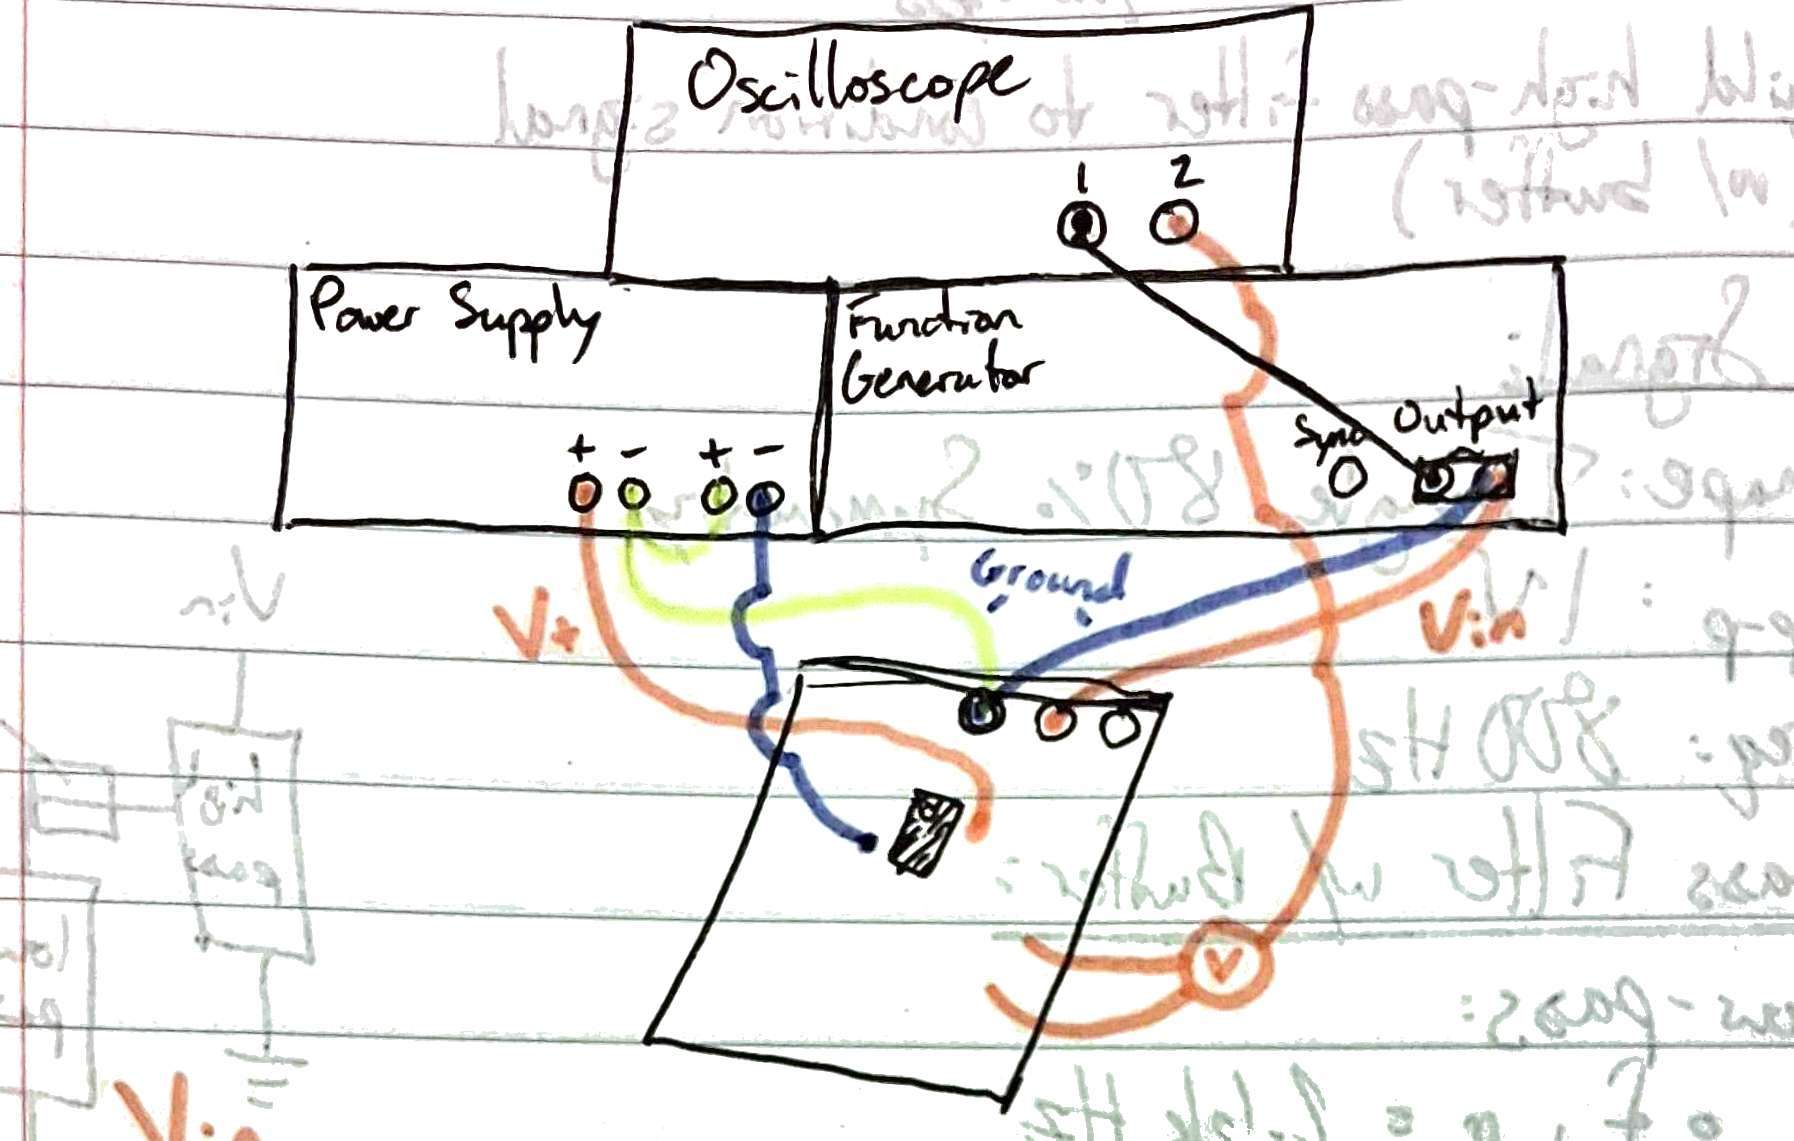

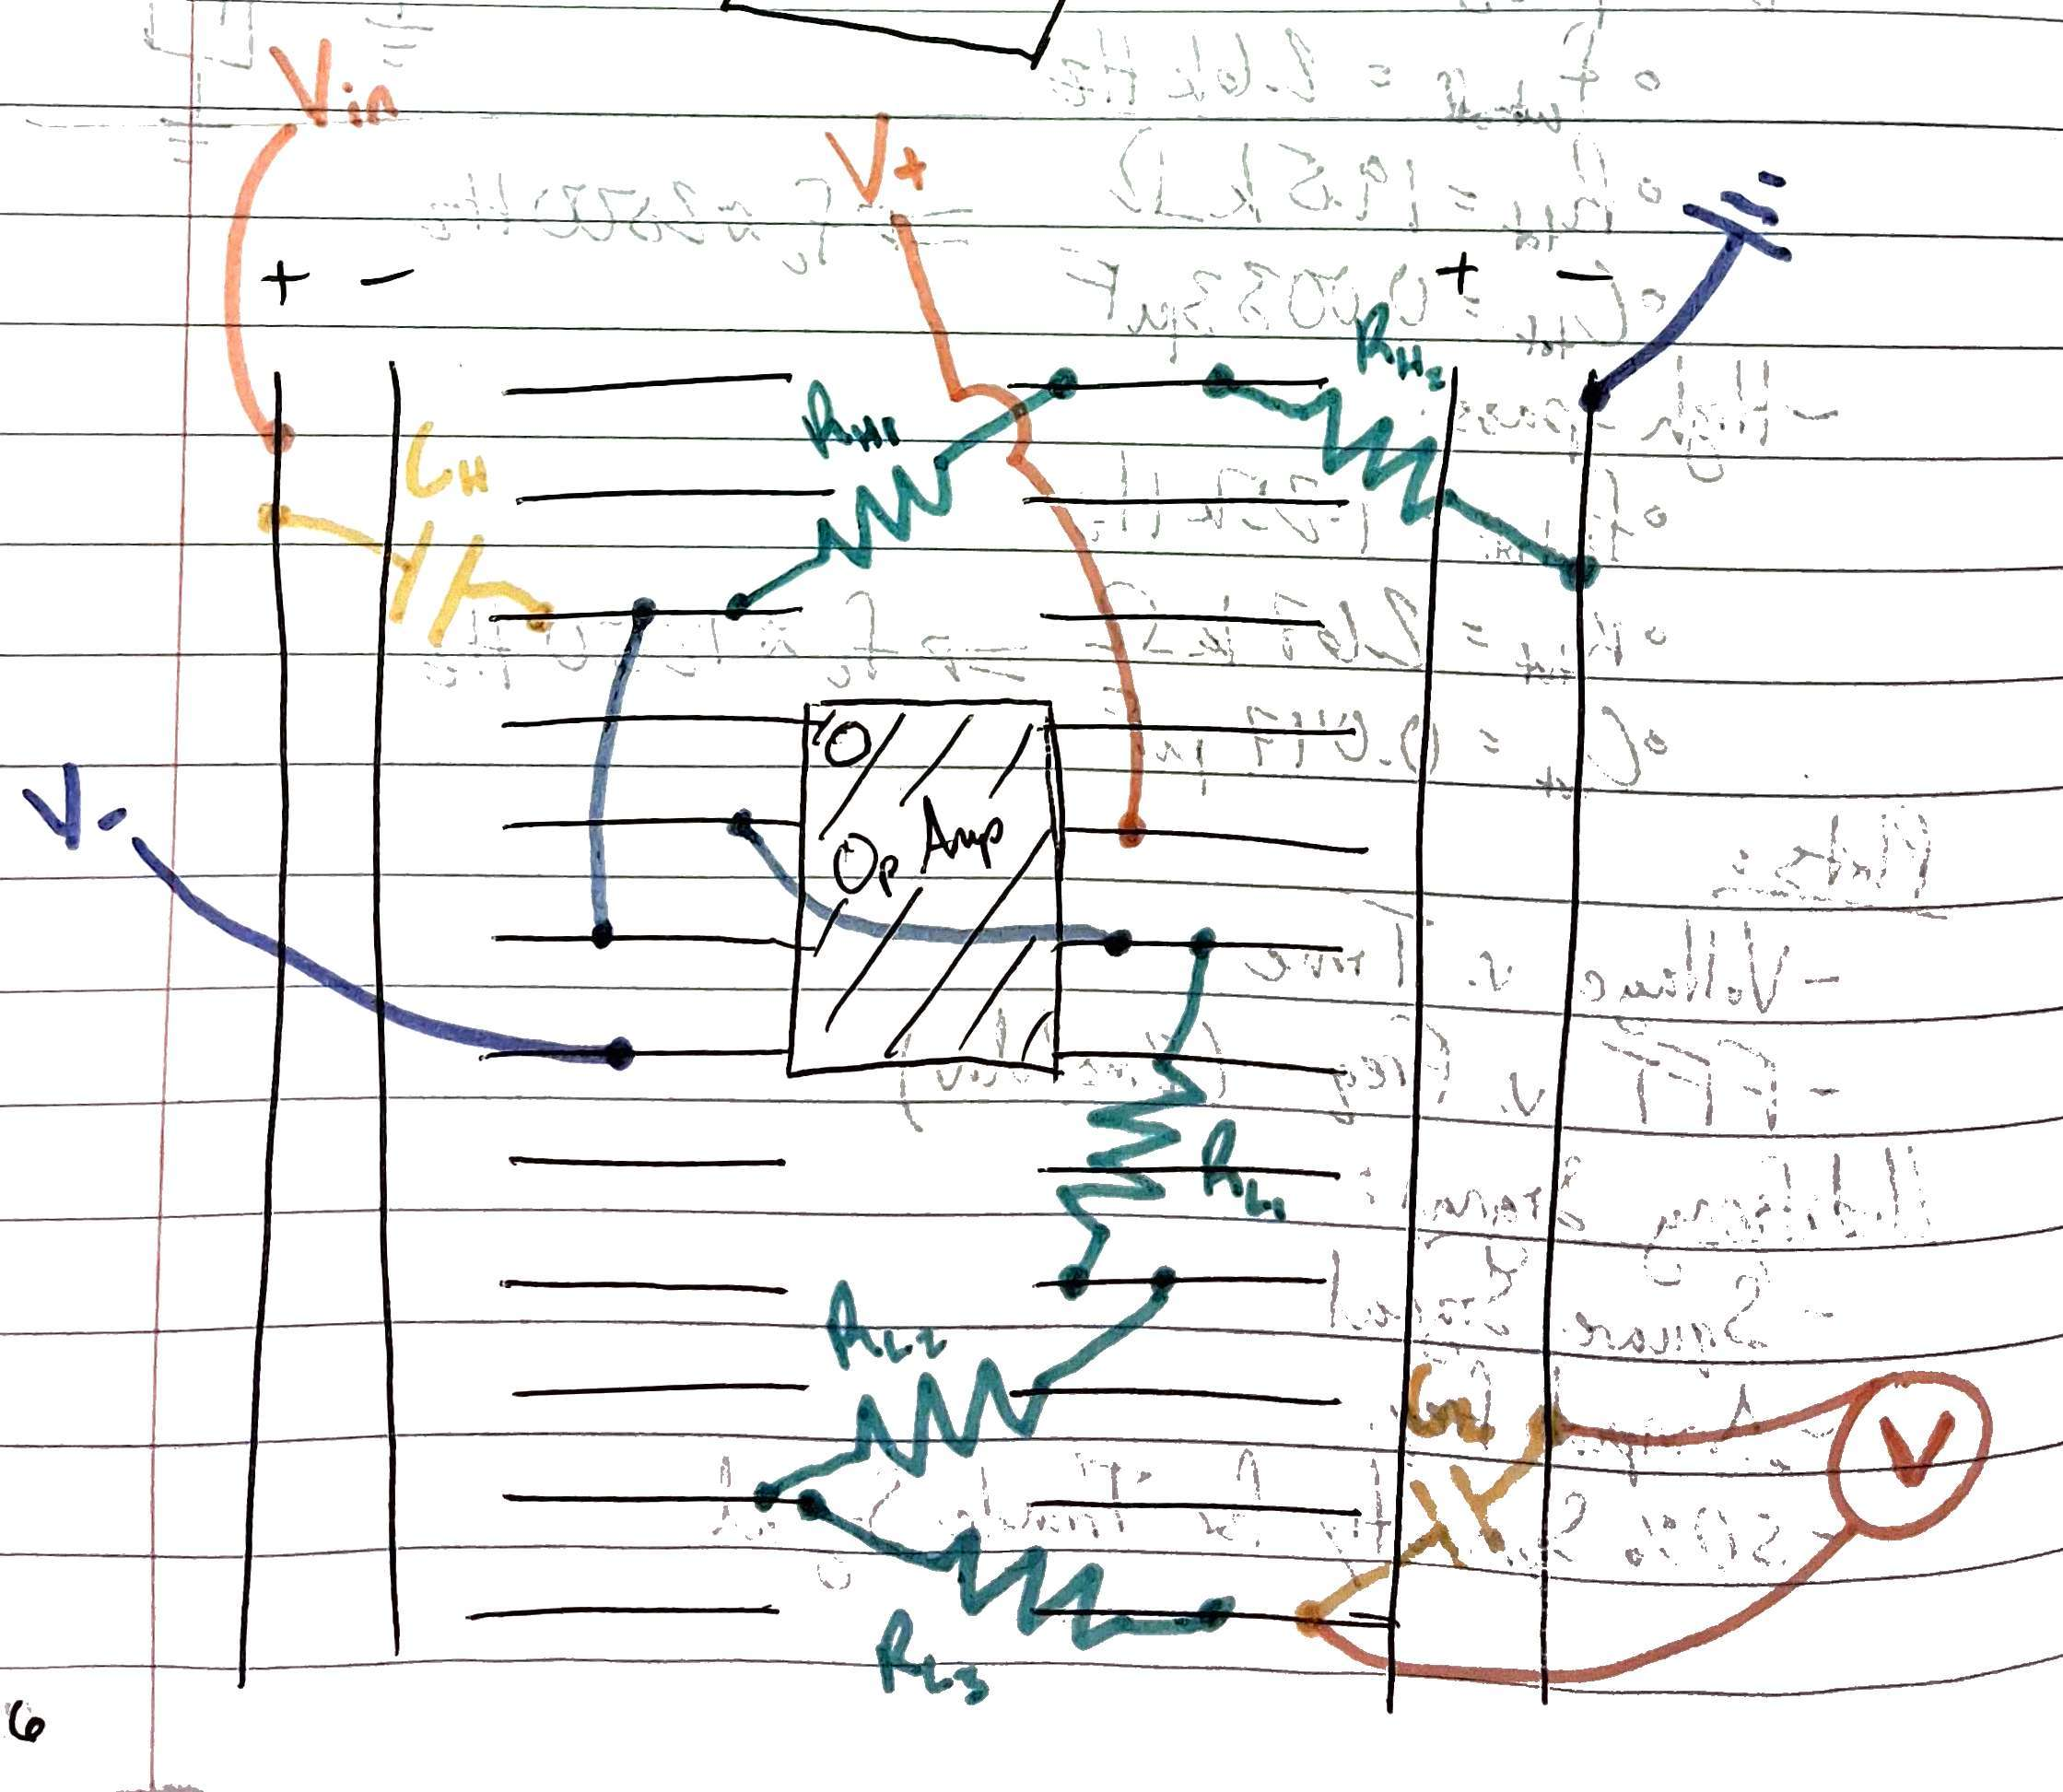

**Triangle Wave Signal**

Shape: Triangle, 80% symmetry <br>
$V_\text{p-p}$ = 1 V <br>
Frequency = 800 Hz

In [ ]:
#Data Taking Code
    #Peak-to-peak voltage
    #Phase difference
    #FFT graph

In [37]:
timescale = float(osc.query(":TIM:SCAL?")) # time scale as a real number
print('tscale =',timescale, 'seconds/div')
vscale1 = float(osc.query("CHAN1:SCALE?")) # voltage scale as a real number
print('vscale1 =',vscale1, 'volts/div')
vscale2 = float(osc.query("CHAN2:SCALE?"))
print('vscale2 =',vscale2, 'volts/div')
freqfftscale = float(osc.query(":TIM:SCAL?"))
print('tfftscale =',timefftscale, 'freq/div')
fftscale = 0.05
print('fftscale =',fftscale, 'volts/div')

tscale = 0.005 seconds/div
vscale1 = 0.5 volts/div
vscale2 = 0.5 volts/div
tfftscale = 0.005 freq/div
fftscale = 0.05 volts/div


In [18]:
#Unfiltered Signal
osc.write(":WAVeform:SOURce CHANnel1")      # get data from Channel 1 as "source"
osc.write(":WAVeform:FORMat ASCII")         # data format, ASCII strings
volt_stringdata = osc.query_ascii_values(":WAVeform:DATA?","s") # get data as ASCII strings
vunfiltered = np.array(volt_stringdata[1:],dtype = np.float64)   # convert strings to numbers (float)
start = 0.0                    # start of time axis
N = len(volt_numdata)
stop = timescale*10  # end of time axis
time_axis = np.linspace(start,stop,num = N) # time axis points

In [19]:
#Filtered Signal
osc.write(":WAVeform:SOURce CHANnel2")
osc.write(":WAVeform:FORMat ASCII")
volt_stringdata = osc.query_ascii_values(":WAVeform:DATA?","s")
vfiltered = np.array(volt_stringdata[1:],dtype = np.float64)
start = 0.0
N = len(volt_numdata)
stop = timescale*10
time_axis = np.linspace(start,stop,num = N)

<span style="background-color:yellow">
Voltage Signal Graph<br>
- Blue: Unfiltered<br>
- Red: Filtered
</span>

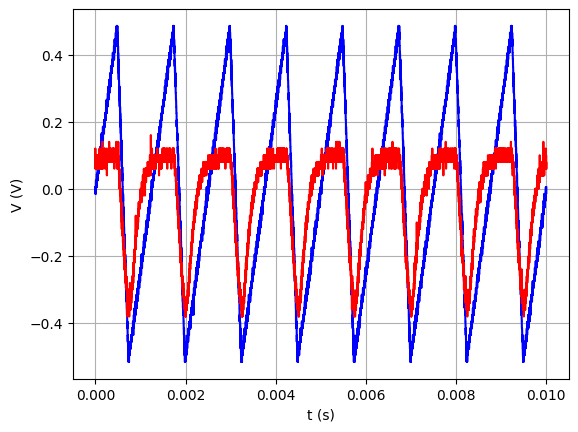

In [20]:
plt.plot(time_axis, vunfiltered,'b-')
plt.plot(time_axis, vfiltered, 'r-')
plt.xlabel('t (s)')
plt.ylabel('V (V)')
plt.grid(True)
plt.savefig('Signal_1_2_18Feb2026.png')

In [21]:
print(time_axis)
print(vunfiltered)
print(vfiltered)

[0.00000000e+00 2.00008000e-07 4.00016001e-07 ... 9.99959998e-03
 9.99979999e-03 1.00000000e-02]
[ 0.0048995  0.0048995  0.0048995 ...  0.0048995 -0.015201   0.0048995]
[0.080402  0.120603  0.0603015 ... 0.0603015 0.0603015 0.0603015]


In [47]:
osc.write(":WAVeform:SOURce MATH")
osc.write(":WAVeform:FORMat ASCII")
volt_stringdata = osc.query_ascii_values(":WAVeform:DATA?","s")
fft_filtered = np.array(volt_stringdata[1:],dtype = np.float64)
start = 0.0
N = len(fft_filtered)
stop = freqfftscale*10
freq_axis = np.linspace(start,stop,num = N)                                                     

print(freq_axis)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
print(fft_filtered)

[0.         0.00010917 0.00021834 0.00032751 0.00043668 0.00054585
 0.00065502 0.00076419 0.00087336 0.00098253 0.0010917  0.00120087
 0.00131004 0.00141921 0.00152838 0.00163755 0.00174672 0.0018559
 0.00196507 0.00207424 0.00218341 0.00229258 0.00240175 0.00251092
 0.00262009 0.00272926 0.00283843 0.0029476  0.00305677 0.00316594
 0.00327511 0.00338428 0.00349345 0.00360262 0.00371179 0.00382096
 0.00393013 0.0040393  0.00414847 0.00425764 0.00436681 0.00447598
 0.00458515 0.00469432 0.00480349 0.00491266 0.00502183 0.005131
 0.00524017 0.00534934 0.00545852 0.00556769 0.00567686 0.00578603
 0.0058952  0.00600437 0.00611354 0.00622271 0.00633188 0.00644105
 0.00655022 0.00665939 0.00676856 0.00687773 0.0069869  0.00709607
 0.00720524 0.00731441 0.00742358 0.00753275 0.00764192 0.00775109
 0.00786026 0.00796943 0.0080786  0.00818777 0.00829694 0.00840611
 0.00851528 0.00862445 0.00873362 0.00884279 0.00895197 0.00906114
 0.00917031 0.00927948 0.00938865 0.00949782 0.00960699 0.0097161

In [50]:
df = []
df = pd.DataFrame(fft_filtered)
df.to_csv('lab5_fft_filtered_18Feb2026.csv', index = False)

In [51]:
osc.write(":WAVeform:SOURce MATH")
osc.write(":WAVeform:FORMat ASCII")
volt_stringdata = osc.query_ascii_values(":WAVeform:DATA?","s")
fft_unfiltered = np.array(volt_stringdata[1:],dtype = np.float64)
start = 0.0
N = len(fft_unfiltered)
stop = freqfftscale*10
freq_axis = np.linspace(start,stop,num = N)   

In [52]:
df = []
df = pd.DataFrame(fft_unfiltered)
df.to_csv('lab5_fft_unfiltered_18Feb2026.csv', index = False)

In [ ]:
osc.write(":WAVeform:SOURce MATH")
osc.write(":WAVeform:FORMat ASCII")
volt_stringdata = osc.query_ascii_values(":WAVeform:DATA?","s")
fft_hp = np.array(volt_stringdata[1:],dtype = np.float64)
start = 0.0
N = len(fft_hp)
stop = freqfftscale*10
freq_axis = np.linspace(start,stop,num = N)   

<span style="background-color:yellow">
FFT over Frequency Graph<br> 
- Blue: Unfiltered<br>
- Red: Filtered </span>

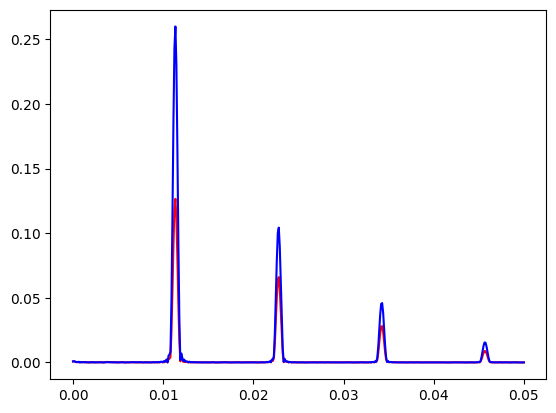

In [53]:
plt.plot(freq_axis, fft_filtered, 'r-')
plt.plot(freq_axis, fft_unfiltered, 'b-')
plt.plot()
plt.xlabel('Freq (Hz)')
plt.ylabel('Voltage (V)')

**Circuit Gain Measurements**

High Pass

In [86]:
freq = np.linspace(100, 3000, 30)
Vsignal = []
Vfiltered = []
import time 
for setfreq in freq:
    freqstr = "APPL:SIN " + str(setfreq) + ", 1" 
    gen.write(freqstr)
    readVin = scope.query(":MEASure:VPP? CHANnel1")
    Vsignal.append(float(readVin))
    readVout = scope.query(":MEASure:VPP? CHANnel2")
    Vfiltered.append(float(readVout))
    time.sleep(2)

In [ ]:
print(Vsignal)
print(Vfiltered)
print(time)

In [88]:
Vin = np.array(Vsignal)
Vout = np.array(Vfiltered)
gainhigh = Vout / Vin
print(gainhigh)

[0.13333333 0.20952381 0.28571429 0.36190476 0.4        0.45714286
 0.54368932 0.57142857 0.62135922 0.66019417 0.68571429 0.73267327
 0.75247525 0.77227723 0.81188119 0.81188119 0.83168317 0.87128713
 0.85436893 0.87128713 0.87128713 0.91089109 0.91089109 0.89320388
 0.93069307 0.93069307 0.93203883 0.95049505 0.95049505 0.95049505]


In [92]:
df = []
df = pd.DataFrame(gainhigh)
df.to_csv('lab5_gain_high_18Feb2026.csv', index = False)
df = []
df = pd.DataFrame(freq)
df.to_csv('lab5_freq_high_18Feb2026.csv', index = False)

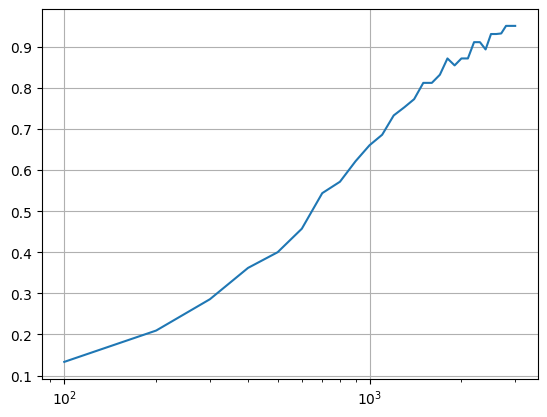

In [89]:
plt.semilogx(freq, gainhigh, '-')
plt.grid(True)

Low Pass

In [68]:
freq = np.linspace(1000, 3900, 30)
Vsignal = []
Vfiltered = []
import time 
for setfreq in freq:
    freqstr = "APPL:SIN " + str(setfreq) + ", 1" 
    gen.write(freqstr)
    readVin = scope.query(":MEASure:VPP? CHANnel1")
    Vsignal.append(float(readVin))
    readVout = scope.query(":MEASure:VPP? CHANnel2")
    Vfiltered.append(float(readVout))
    time.sleep(2.5)

In [72]:
Vin = np.array(Vsignal)
Vout = np.array(Vfiltered)
gainlow = Vout / Vin
print(gainlow)

[0.8952381  0.91428571 0.93333333 0.87619048 0.87619048 0.85714286
 0.83809524 0.83809524 0.81904762 0.78095238 0.78095238 0.76190476
 0.76190476 0.74285714 0.72380952 0.72380952 0.7047619  0.68571429
 0.68571429 0.66666667 0.66666667 0.64761905 0.64761905 0.62857143
 0.62135922 0.60952381 0.59047619 0.59047619 0.57142857 0.57142857]


In [91]:
df = []
df = pd.DataFrame(gainlow)
df.to_csv('lab5_gain_low_18Feb2026.csv', index = False)
df = []
df = pd.DataFrame(freqlow)
df.to_csv('lab5_freq_low_18Feb2026.csv', index = False)

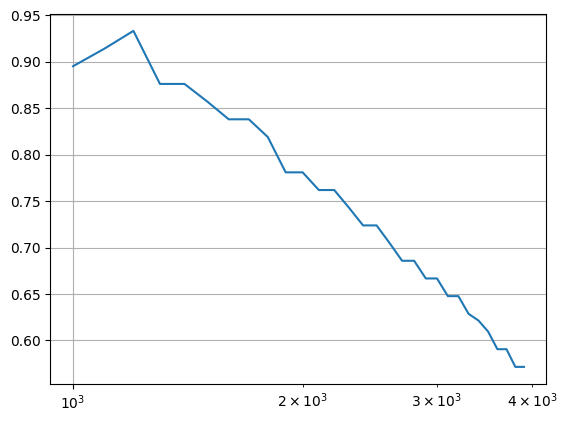

In [90]:
freqlow = np.linspace(1000, 3900, 30)
plt.semilogx(freqlow, gainlow, '-')

plt.grid(True)

Band Pass with Op Amp

In [104]:
freqbp = np.linspace(100, 3600, 18)
Vsignal = []
Vfiltered = []
import time 
for setfreq in freqbp:
    freqstr = "APPL:SIN " + str(setfreq) + ", 1" 
    gen.write(freqstr)
    readVin = scope.query(":MEASure:VPP? CHANnel1")
    Vsignal.append(float(readVin))
    readVout = scope.query(":MEASure:VPP? CHANnel2")
    Vfiltered.append(float(readVout))
    time.sleep(2)

In [105]:
Vin = np.array(Vsignal)
Vout = np.array(Vfiltered)
gainbp = Vout / Vin
print(gainbp)

[0.13333333 0.31067961 0.41904762 0.51428571 0.60194175 0.60952381
 0.66019417 0.69306931 0.69306931 0.69306931 0.69306931 0.67326733
 0.6407767  0.67326733 0.61386139 0.63366337 0.61386139 0.55445545]


In [106]:
df = []
df = pd.DataFrame(gainbp)
df.to_csv('lab5_gain_bp_18Feb2026.csv', index = False)
df = []
df = pd.DataFrame(freqbp)
df.to_csv('lab5_freq_bp_18Feb2026.csv', index = False)

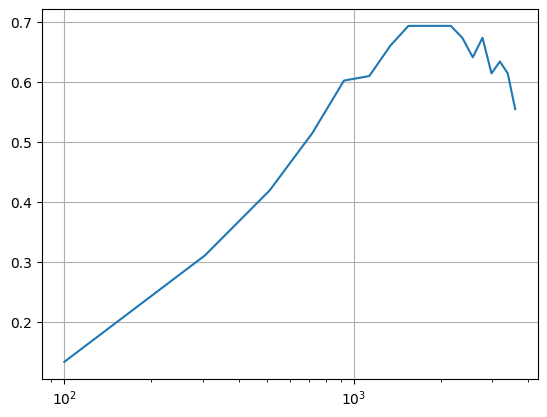

In [107]:
plt.semilogx(freqbp, gainbp, '-')

plt.grid(True)

**Brief conclusion about band-pass w/ buffer circuits ability to filter frequency signals as desired**

<span style="background-color:yellow"> 
The goal of the circuit was to filter the frequency signals so that only two frequencies -roughly 1500 Hz and 2250 Hz- were retained. The circuit was designed to filter between the range of 1250 Hz and 2500 Hz. <br>
The resultant frequency signal filtration done by band-pass circuit with an op-amp is a bit mixed. It certainly was filtering the input signal and reducing the frequency signals, but this filtering (a peak voltage reduction of about 40-50%) was done near equaly across the four frequencies seen between 0 and 3500 Hz, including the two desired frequencies. <br>
Tests were done forthwith to ascertain the source of the issue via voltage measurements to produce gain over frequency plots. Looking at the gain plots, the high-pass circuit was performing as expected, producing gain values between 20 and 60% before 1000 Hz with significant gain values of 70% or more beyond that frequency. The low-pass circuit appears to have performed less successfully. Gain between 1000 and 2000 Hz dropped from 95% to 78%, but only had a gradual decline beyond that, with 4000 Hz still giving a gain of over 60%.<br>
Overall, the circuit was successful in reducing frequency signals, but was unsuccessful in being accurate according to its goals and could not reduce undesired frequencies to a greater degree than the desired frequencies.<br>
It should be noted that after the plots were done it was realized that they did not have axis titles (and some of them not even proper axis values, such as for the fft graph). This was not realized until after data taking had concluded (which data was also not saved and stored properly) and as such made it impossible to replot the data with proper axis values and titles.</span>

**Modified Wave Signal**

- Triangle Signal at 50% symmetry

In [ ]:
#Data Taking Code
    #Peak-to-peak voltage
    #Phase difference
    #FFT graph

In [ ]:
#Data saving

In [ ]:
#Data Plotting
    #Peak-to-peak voltage
    #Phase difference
    #FFT graph
 #Save graphs

Brief conclusion about how modifing the signal did or did not cause the circuit to fail its purpose

- Different Input Frequency
- 300 Hz
- 1500 Hz
- 2000 Hz

In [ ]:
#Data Taking Code
    #Peak-to-peak voltage
    #Phase difference
    #FFT graph

In [ ]:
#Data saving

In [ ]:
#Data Plotting
    #Peak-to-peak voltage
    #Phase difference
    #FFT graph
 #Save graphs

Brief conclusion about how modifing the signal did or did not cause the circuit to fail its purpose

- Square Signal

In [ ]:
#Data Taking Code
    #Peak-to-peak voltage
    #Phase difference
    #FFT graph

In [ ]:
#Data saving

In [ ]:
#Data Plotting
    #Peak-to-peak voltage
    #Phase difference
    #FFT graph
 #Save graphs

Brief conclusion about how modifing the signal did or did not cause the circuit to fail its purpose

**Explanation for Parts Two and Three**

<span style="background-color:yellow">Planning out and working on Part 1 of this lab took much longer than expected. As previously explained, issues with the resultant data led to an exorbitant time spent on troubleshooting to determine the source of the unpredicted filtering. As such, no work was done on parts 2 and 3. </span>

## 2. Signal is "too big"

Perhaps your signal is larger than the input limits of your interface so you need to make it smaller.

### Signal reduction

* **GOAL**: Create a circuit that takes signals (both DC and AC) in the range $\pm20\ \text{V}$ and delivers proportional corresponding signals in the range $\pm 10\ \text{V}$ ($4\ \text{V}$ goes to $2\ \text{V}$, ..., $20\ \text{V}$ goes to $10\ \text{V}$). 


--- 
**RESPONSE: Signal reduction**

<span style="background-color:yellow">Put your schematic, data, graphs, and explanation below.</span>


---

## 3. Signal "too small"

### Signal amplification

* **GOAL**: A circuit that takes signals (both DC and AC) in the range $\pm 100\ \text{mV}$ and delivers proportional corresponding output signals in roughly the range $\pm 10\ \text{V}$ ($100\ \text{mV}$ becomes $1\ \text{V}$, $200\ \text{mV}$ becomes $2\ \text{V}$, etc.) 

---  

### Option:  Op-amp: (non-inverting) amplifier 

You may choose to use a (typical) non-inverting op-amp arrangement.

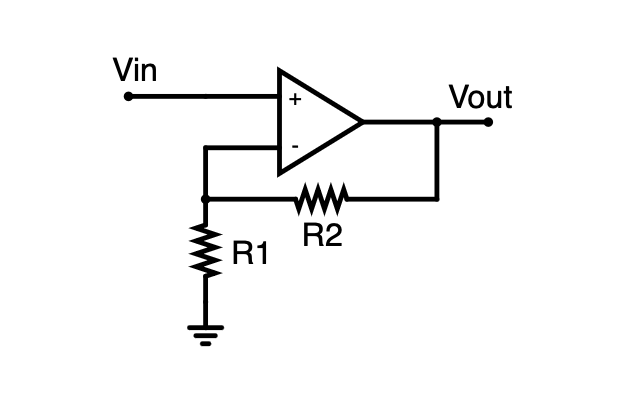

Figure: Non-inverting op-amp.

The gain of this circuit is given by 
$$ G = \frac{V_\text{out}}{V_\text{in}}= 1+\frac{R_2}{R_1}$$

--- 

**RESPONSE: Signal amplification**

<span style="background-color:yellow">Put your schematic, data, graphs, and explanation below.</span>


---